# 07 — The shapelet score as a nightly image-quality monitor

Produces:
* `fig/score_timeseries.pdf` (`fig:timeseries`) — visit-median shapelet score against
  time, coloured by band, over the whole 2025-04 to 2026-05 baseline.
* `fig/nightly_tiers.pdf` (`fig:nightly`) — stacked bar chart of the fraction of
  (visit, raft) PSFs in each quality tier, per night.

The second figure is the operational product: one bar per night, immediately showing
whether the optics were behaving.

In [1]:
import importlib.util
spec = importlib.util.spec_from_file_location('plot_config', 'plot_config.py')
plot_config = importlib.util.module_from_spec(spec); spec.loader.exec_module(plot_config)
from plot_config import (BANDS, BAND_COLORS, PALETTE, TIER_EDGES, TIER_COLORS, TIERS,
                         FIG, MultipleLocator, apply_style, bvec_path, shapelet_score,
                         classify_tier, day_obs, detector_to_raft, SCIENCE_RAFTS)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

apply_style()
EPOCHS = {'DP2': 'dp2all', 'Post-DP2': 'postdp2'}
det2raft = detector_to_raft()

rows = []
for epoch, tag in EPOCHS.items():
    for band in BANDS:
        d = np.load(bvec_path(band, tag))
        rows.append(pd.DataFrame(dict(
            epoch=epoch, band=band,
            visit=d['visit'].astype(np.int64),
            raft=[det2raft.get(int(x), 'unknown') for x in d['detector']],
            score=shapelet_score(d['bvec']))))
df = pd.concat(rows, ignore_index=True)
df = df[df.raft.isin(SCIENCE_RAFTS)]
df['night'] = day_obs(df['visit'].values)
df['date'] = pd.to_datetime(df['night'].astype(str), format='%Y%m%d')
print(f'{len(df):,} PSFs, {df.night.nunique()} nights, '
      f'{df.date.min().date()} to {df.date.max().date()}')

1,468,222 PSFs, 209 nights, 2025-04-24 to 2026-05-13


## Figure: score time series

69,053 (visit, band) points
209 nights on a gap-free axis


wrote /sdf/data/rubin/user/ztq1996/psf-rubin/psf_zernike/shapelet_score_paper/fig/score_timeseries.pdf -- 5 rows of ~42 nights


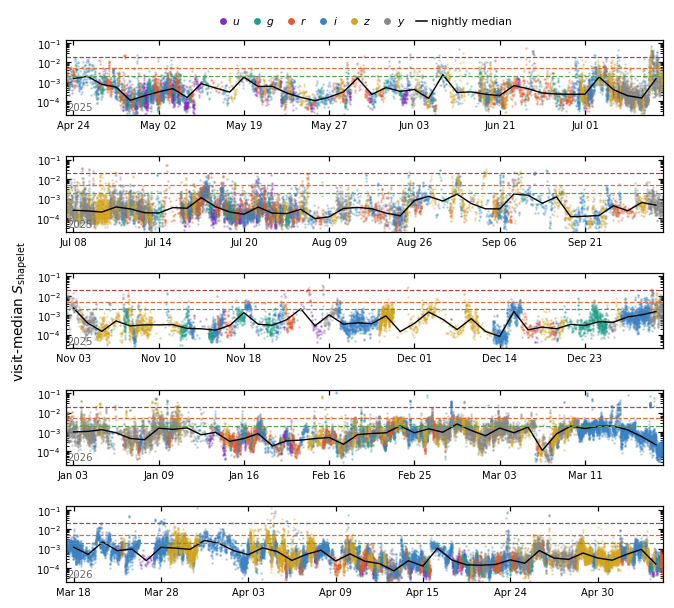

In [2]:
# One point per (visit, band): the median score over that visit's rafts.
vis = df.groupby(['visit', 'band', 'date'], as_index=False)['score'].median()
print(f'{len(vis):,} (visit, band) points')

# Gap-free horizontal axis: nights are placed consecutively regardless of the
# calendar interval between them, and visits are spread evenly within a night.
nights = np.sort(vis['date'].unique())
night_idx = {d: i for i, d in enumerate(nights)}
vis = vis.sort_values(['date', 'visit']).copy()
vis['ni'] = vis['date'].map(night_idx)
rank = vis.groupby('date').cumcount()
size = vis.groupby('date')['visit'].transform('size')
vis['x'] = vis['ni'] + (rank + 0.5) / size
print(f'{len(nights)} nights on a gap-free axis')

nightly = vis.groupby('ni', as_index=False)['score'].median()

NROW = 5
per_row = int(np.ceil(len(nights) / NROW))
fig, axes = plt.subplots(NROW, 1, figsize=(7.0, 6.4),
                         gridspec_kw=dict(hspace=0.55))

for k, ax in enumerate(axes):
    lo, hi = k * per_row, min((k + 1) * per_row, len(nights))
    sel = vis[(vis.ni >= lo) & (vis.ni < hi)]
    for band in BANDS:
        s = sel[sel.band == band]
        ax.plot(s['x'], s['score'], '.', ms=1.2, alpha=0.35,
                color=BAND_COLORS[band], rasterized=True)
    ns = nightly[(nightly.ni >= lo) & (nightly.ni < hi)]
    ax.plot(ns['ni'] + 0.5, ns['score'], color='k', lw=0.9)

    for e, name in zip(TIER_EDGES, ['MEDIUM', 'HIGH', 'VERY HIGH']):
        ax.axhline(e, color=TIER_COLORS[name], ls='--', lw=0.8)

    ax.set_yscale('log')
    ax.set_ylim(2e-5, 1.5e-1)
    ax.set_xlim(lo, hi)
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_yticks([1e-4, 1e-3, 1e-2, 1e-1])
    ax.yaxis.set_minor_locator(plt.LogLocator(base=10, subs=np.arange(2, 10),
                                              numticks=12))
    ax.tick_params(axis='y', labelsize=6.5)

    # Date ticks every ~10 nights within the row.
    step = max(1, per_row // 7)
    tick_ni = np.arange(lo, hi, step)
    ax.set_xticks(tick_ni + 0.5)
    ax.set_xticklabels([pd.Timestamp(nights[i]).strftime('%b %d') for i in tick_ni],
                       fontsize=6.5)
    # Year label at the left of each row.
    ax.text(0.002, 0.06, pd.Timestamp(nights[lo]).strftime('%Y'),
            transform=ax.transAxes, fontsize=6.5, color='0.4')

axes[NROW // 2].set_ylabel(r'visit-median $S_{\rm shapelet}$')

handles = [plt.Line2D([], [], marker='o', ls='', ms=3.5, color=BAND_COLORS[b], label=f'${b}$')
           for b in BANDS]
handles.append(plt.Line2D([], [], color='k', lw=1.0, label='nightly median'))
axes[0].legend(handles=handles, ncol=7, frameon=False, fontsize=7,
               loc='lower center', bbox_to_anchor=(0.5, 1.02), handlelength=1.0,
               columnspacing=1.0, handletextpad=0.4)

fig.savefig(FIG / 'score_timeseries.pdf', dpi=250)
print('wrote', FIG / 'score_timeseries.pdf', f'-- {NROW} rows of ~{per_row} nights')

## Figure: nightly tier fractions

In [3]:
# Classify each (visit, raft) PSF, then take the fraction per tier per night.
df['tier'] = classify_tier(df['score'].values)
TIER_NAMES = [t[0] for t in TIERS]

cnt = (df.groupby(['date', 'tier']).size().unstack(fill_value=0)
         .reindex(columns=TIER_NAMES, fill_value=0))
n_per_night = cnt.sum(axis=1)
frac = cnt.div(n_per_night, axis=0)

# Require a minimum number of PSFs for a night to be plotted.
MIN_PSF = 200
keep = n_per_night >= MIN_PSF
frac, n_per_night = frac[keep], n_per_night[keep]
print(f'{keep.sum()} of {len(keep)} nights have >= {MIN_PSF} PSFs '
      f'({n_per_night.sum():,} PSFs plotted)')
print(f'median PSFs per plotted night: {n_per_night.median():.0f}')

206 of 209 nights have >= 200 PSFs (1,467,760 PSFs plotted)
median PSFs per plotted night: 6104


wrote /sdf/data/rubin/user/ztq1996/psf-rubin/psf_zernike/shapelet_score_paper/fig/nightly_tiers.pdf
206 nights plotted; 12 of 14 month labels shown; max stacked fraction = 0.65


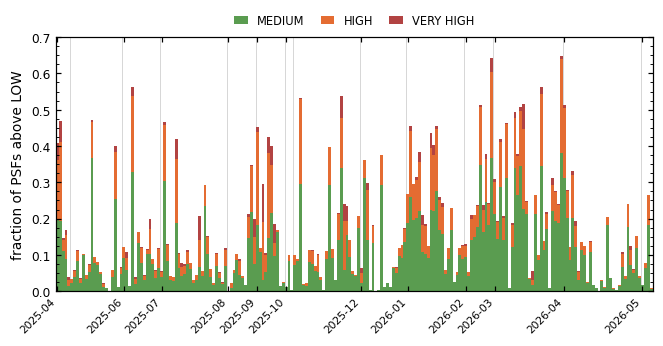

In [4]:
# Plot nights sequentially rather than on a calendar axis: the observing
# cadence is irregular, and a calendar axis turns 206 nights into hairlines
# separated by white space. Ticks are placed at the first observed night of
# each month, so the horizontal axis still reads as a date.
x = np.arange(len(frac))
dates = frac.index

fig, ax = plt.subplots(figsize=(7.0, 3.0))

# LOW is omitted: it occupies 80-100% of every bar and would compress the
# part of the plot that carries the information.
SHOW = ['MEDIUM', 'HIGH', 'VERY HIGH']
bottom = np.zeros(len(frac))
for name in SHOW:
    ax.bar(x, frac[name].values, bottom=bottom, width=1.0,
           color=TIER_COLORS[name], label=name, linewidth=0)
    bottom += frac[name].values

ax.set_xlim(-0.5, len(frac) - 0.5)
ax.set_ylim(0, min(1.0, bottom.max() * 1.08))
ax.set_ylabel('fraction of PSFs above LOW')
ax.yaxis.set_minor_locator(MultipleLocator(0.025))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.xaxis.set_minor_locator(plt.NullLocator())

# Month boundaries at the first observed night of each month. Months with only
# a night or two would produce overlapping labels, so drop any tick closer than
# MIN_SEP bars to the previous one (the boundary line is still drawn).
per = dates.to_period('M')
first = {p: i for i, p in reversed(list(enumerate(per)))}
bounds = sorted(first.values())
MIN_SEP = 8
ticks, last = [], -MIN_SEP
for i in bounds:
    if i - last >= MIN_SEP:
        ticks.append(i); last = i
ax.set_xticks(ticks)
ax.set_xticklabels([dates[i].strftime('%Y-%m') for i in ticks],
                   rotation=45, ha='right', fontsize=7)
for i in bounds:
    ax.axvline(i - 0.5, color='0.8', lw=0.5, zorder=0)

ax.legend(ncol=3, frameon=False, fontsize=7.5, loc='lower center',
          bbox_to_anchor=(0.5, 1.0), handlelength=1.2, columnspacing=1.4)

fig.savefig(FIG / 'nightly_tiers.pdf')
print('wrote', FIG / 'nightly_tiers.pdf')
print(f'{len(frac)} nights plotted; {len(ticks)} of {len(bounds)} month labels shown; '
      f'max stacked fraction = {bottom.max():.2f}')

In [5]:
# Numbers for the text.
bad = frac['HIGH'] + frac['VERY HIGH']
print(f'fraction of PSFs in HIGH or VERY HIGH, per night:')
print(f'  median over nights = {bad.median()*100:.1f}%')
print(f'  10th-90th pct      = {bad.quantile(0.1)*100:.1f}% - {bad.quantile(0.9)*100:.1f}%')
print(f'  worst 5 nights:')
for d, v in bad.nlargest(5).items():
    print(f'    {d.date()}  {v*100:5.1f}%  ({int(n_per_night[d]):,} PSFs)')
print(f'  best 5 nights:')
for d, v in bad.nsmallest(5).items():
    print(f'    {d.date()}  {v*100:5.1f}%  ({int(n_per_night[d]):,} PSFs)')

print(f'\nnight-to-night scatter of the bad fraction: '
      f'sd = {bad.std()*100:.1f} percentage points')
print(f'ratio worst/median night = {bad.max()/bad.median():.1f}x')

# Monthly summary
print('\nmonthly mean of the HIGH+VERY HIGH fraction:')
mm = bad.groupby(bad.index.to_period('M')).mean()
for k, v in mm.items():
    print(f'  {k}: {v*100:5.1f}%')

fraction of PSFs in HIGH or VERY HIGH, per night:
  median over nights = 3.2%
  10th-90th pct      = 0.1% - 16.4%
  worst 5 nights:
    2026-03-13   28.9%  (5,662 PSFs)
    2025-09-13   27.7%  (2,128 PSFs)
    2025-04-25   27.6%  (1,888 PSFs)
    2026-02-28   27.6%  (12,358 PSFs)
    2025-09-02   27.0%  (4,039 PSFs)
  best 5 nights:
    2025-05-25    0.0%  (2,596 PSFs)
    2025-05-27    0.0%  (1,743 PSFs)
    2025-05-30    0.0%  (2,310 PSFs)
    2025-08-06    0.0%  (1,743 PSFs)
    2025-09-20    0.0%  (2,069 PSFs)

night-to-night scatter of the bad fraction: sd = 7.0 percentage points
ratio worst/median night = 9.2x

monthly mean of the HIGH+VERY HIGH fraction:
  2025-04:  12.6%
  2025-05:   2.5%
  2025-06:   4.8%
  2025-07:   4.6%
  2025-08:   4.0%
  2025-09:  11.5%
  2025-10:   0.5%
  2025-11:   5.3%
  2025-12:   3.1%
  2026-01:   9.0%
  2026-02:   9.5%
  2026-03:   9.2%
  2026-04:   3.3%
  2026-05:   2.4%
